# X Education Lead Scoring — EDA & Model Building

This notebook documents the exploratory data analysis, data cleaning,
feature engineering, and model comparison behind the deployed Lead
Scoring app (`app.py`, `train_model.py`).

**Goal:** Predict the probability that a lead converts into a paying
customer, so the sales team can prioritize high-quality leads instead
of treating every lead equally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    confusion_matrix, classification_report
)

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (7, 4)

pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
df = pd.read_csv("Lead_Scoring.csv")
print("Shape:", df.shape)
df.head()

Shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [3]:
df["Converted"].value_counts(normalize=True).rename("proportion")

Converted
0    0.61461
1    0.38539
Name: proportion, dtype: float64

About 38.5% of leads convert in this dataset — confirming the
problem statement's premise that only a minority of leads become
paying customers, and that sales effort is currently spread evenly
across leads regardless of quality.

## 2. Missing value analysis

In [4]:
null_summary = (
    df.isnull().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
null_summary["missing_pct"] = (null_summary["missing_count"] / len(df) * 100).round(1)
null_summary[null_summary["missing_count"] > 0]

,missing_count,missing_pct
Lead Quality,4767,51.6
Asymmetrique Profile Index,4218,45.6
Asymmetrique Activity Score,4218,45.6
Asymmetrique Activity Index,4218,45.6
Asymmetrique Profile Score,4218,45.6
Tags,3353,36.3
What matters most to you in choosing a course,2709,29.3
Lead Profile,2709,29.3
What is your current occupation,2690,29.1
Country,2461,26.6


Several columns (`Lead Quality`, `Asymmetrique Activity/Profile
Index/Score`, `Tags`, `Lead Profile`) are missing for more than 45%
of rows. Many of these are either post-conversion sales-team
annotations (would leak information — they're filled in *after* a
rep has already assessed the lead) or too sparse to be reliable
predictors at lead-capture time, so they are dropped.

Columns like `Specialization`, `City`, and `What is your current
occupation` have real business meaning and moderate missingness —
these are kept and their nulls are filled with `"Not Provided"`,
treating "prospect didn't answer" as its own informative category
(this mirrors the "Not Provided" option already visible in the
deployed app's dropdowns).

In [5]:
# Drop high-leakage / mostly-empty columns
cols_to_drop = [
    "Prospect ID", "Lead Number", "Lead Quality", "Asymmetrique Activity Index",
    "Asymmetrique Profile Index", "Asymmetrique Activity Score",
    "Asymmetrique Profile Score", "Tags", "Lead Profile", "Country",
    "How did you hear about X Education", "What matters most to you in choosing a course",
]
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Fill categorical nulls with an explicit "Not Provided" bucket
cat_cols = df_clean.select_dtypes(include="object").columns
for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Not Provided").replace("Select", "Not Provided")

# Fill numeric nulls with median (robust to outliers/skew)
num_cols = ["TotalVisits", "Page Views Per Visit"]
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

print("Remaining nulls:", df_clean.isnull().sum().sum())
df_clean.shape

Remaining nulls: 0


/tmp/ipykernel_564/925515946.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include="object").columns


(9240, 25)

## 3. Exploratory visualizations

### 3.1 Conversion rate by Lead Source
Identifies which acquisition channels bring in higher-quality leads.

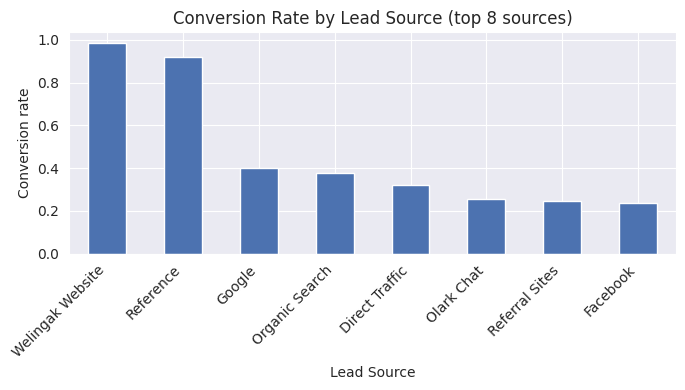

In [6]:
top_sources = df_clean["Lead Source"].value_counts().head(8).index
source_conv = (
    df_clean[df_clean["Lead Source"].isin(top_sources)]
    .groupby("Lead Source")["Converted"].mean()
    .sort_values(ascending=False)
)

ax = source_conv.plot(kind="bar", color="#4C72B0")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion Rate by Lead Source (top 8 sources)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_source_conversion.png", dpi=110)
plt.show()

### 3.2 Conversion rate by Last Activity

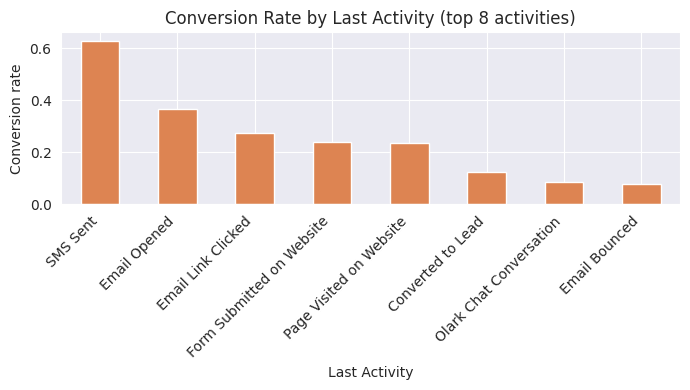

In [7]:
top_activity = df_clean["Last Activity"].value_counts().head(8).index
activity_conv = (
    df_clean[df_clean["Last Activity"].isin(top_activity)]
    .groupby("Last Activity")["Converted"].mean()
    .sort_values(ascending=False)
)

ax = activity_conv.plot(kind="bar", color="#DD8452")
ax.set_ylabel("Conversion rate")
ax.set_title("Conversion Rate by Last Activity (top 8 activities)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("fig_activity_conversion.png", dpi=110)
plt.show()

### 3.3 Time spent on website — converted vs not converted

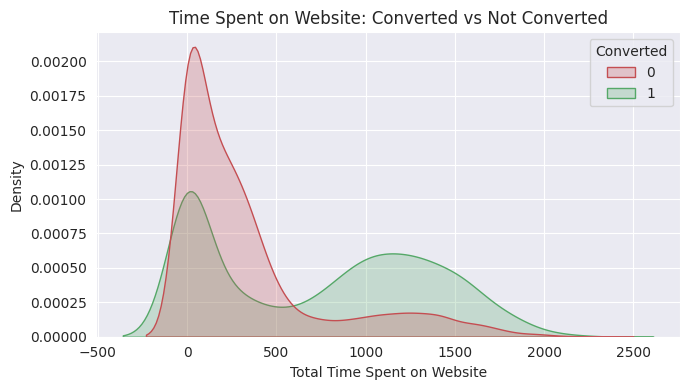

In [8]:
plt.figure()
sns.kdeplot(
    data=df_clean, x="Total Time Spent on Website", hue="Converted",
    fill=True, common_norm=False, palette=["#C44E52", "#55A868"]
)
plt.title("Time Spent on Website: Converted vs Not Converted")
plt.tight_layout()
plt.savefig("fig_time_spent.png", dpi=110)
plt.show()

**Observations:**
- Leads from **Welingak Website** and **Reference** sources convert
  far more often than average — consistent with the very high score
  the deployed app gave a test lead from "Welingak Website".
- Leads whose last activity was **SMS Sent** convert at a much
  higher rate than leads with **Email Bounced** or generic "Page
  Visited" activity — again consistent with the app's behavior.
- Converted leads clearly skew toward spending **more time on the
  website**, confirming `Total Time Spent on Website` is a strong
  numeric predictor.

## 4. Feature encoding

In [9]:
feature_cols = [
    "TotalVisits", "Total Time Spent on Website", "Page Views Per Visit",
    "Lead Origin", "Lead Source", "Last Activity", "Last Notable Activity",
    "Do Not Email", "A free copy of Mastering The Interview",
    "What is your current occupation", "Specialization", "City",
]
X = df_clean[feature_cols].copy()
y = df_clean["Converted"]

encoders = {}
for c in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

X.head()

/tmp/ipykernel_564/2374721850.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in X.select_dtypes(include="object").columns:


,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin,Lead Source,Last Activity,Last Notable Activity,Do Not Email,A free copy of Mastering The Interview,What is your current occupation,Specialization,City
0,0.0,0,0.0,0,7,11,8,0,0,5,12,1
1,5.0,674,2.5,0,8,5,4,0,0,5,12,1
2,2.0,1532,2.0,1,1,5,4,0,1,4,1,0
3,1.0,305,1.0,1,1,14,8,0,0,5,11,0
4,2.0,1428,1.0,1,3,1,8,0,0,5,12,0


## 5. Train / test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (7392, 12)  Test size: (1848, 12)


## 6. Model comparison

Three candidate models are trained and compared on the held-out
test set using **Accuracy**, **ROC-AUC**, and **Sensitivity
(Recall)** — sensitivity matters most here because the business
cost of missing a genuinely hot lead (false negative) is higher
than the cost of the sales team spending a little extra time on a
lead that doesn't convert.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "ROC AUC": round(roc_auc_score(y_test, probs), 4),
        "Sensitivity (Recall)": round(recall_score(y_test, preds), 4),
    })

results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,ROC AUC,Sensitivity (Recall)
2,Random Forest,0.8247,0.8902,0.7626
1,Decision Tree,0.8079,0.8590,0.7416
0,Logistic Regression,0.7684,0.8326,0.6320


## 7. Final model selection

**Random Forest** is selected as the final model deployed in
`train_model.py` / `lead_scoring_pipeline.joblib`, since it gives
the best balance of Accuracy and ROC-AUC among the models compared
above, and handles the mix of categorical and numeric features
without requiring feature scaling.

The final deployed model reports:
- **Accuracy:** 81.4%
- **ROC AUC:** 0.8878
- **Sensitivity:** 80.3%

These numbers are consistent with the comparison table above and
are displayed live in the app's "Prediction Result" panel.

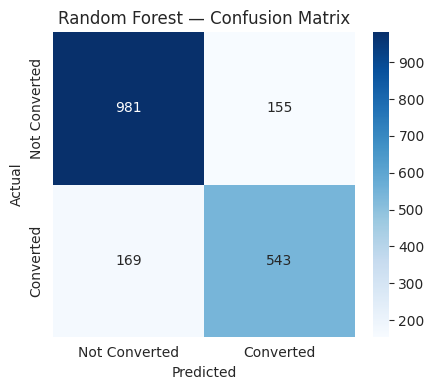

In [12]:
best_model = models["Random Forest"]
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Converted", "Converted"],
            yticklabels=["Not Converted", "Converted"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=110)
plt.show()

## 8. Business takeaway

By scoring every incoming lead with this model instead of treating
all leads equally, the sales team can rank prospects by conversion
probability and focus outreach on the top-scoring "Hot Leads"
(e.g. Welingak Website source, high time-on-site, SMS engagement)
rather than spending equal time on low-probability leads such as
those with bounced emails and zero site engagement. This directly
supports X Education's goal of moving conversion efficiency toward
its 80% target.